2026-06-03 09:39:46.620179: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


生成 30000 个128×128矩阵 (int8)...
完成，耗时 520.34秒，可逆比例 28.67%
添加特殊奇异模式...
增强后数据量: 303000, 可逆比例: 28.38%
训练集: 242400, 测试集: 60600
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 128, 128, 64  1664        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 activation (Activation)        (None, 128, 128, 64  0           ['conv2

2026-06-03 09:48:56.560090: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1943] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-06-03 09:48:56.562559: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1943] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-06-03 09:48:56.564503: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1943] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-06-03 09:48:56.566456: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1943] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX,

                                                                                                  
 activation_3 (Activation)      (None, 32, 32, 128)  0           ['conv2d_3[0][0]']               
                                                                                                  
 batch_normalization_3 (BatchNo  (None, 32, 32, 128)  512        ['activation_3[0][0]']           
 rmalization)                                                                                     
                                                                                                  
 add (Add)                      (None, 32, 32, 128)  0           ['batch_normalization_3[0][0]',  
                                                                  'max_pooling2d_1[0][0]']        
                                                                                                  
 spatial_dropout2d (SpatialDrop  (None, 32, 32, 128)  0          ['add[0][0]']                    
 out2D)   

2026-06-03 09:54:57.977539: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101
2026-06-03 09:58:28.334724: W tensorflow/stream_executor/gpu/asm_compiler.cc:230] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 12.0
2026-06-03 09:58:28.334737: W tensorflow/stream_executor/gpu/asm_compiler.cc:233] Used ptxas at ptxas
2026-06-03 09:58:28.334780: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] UNIMPLEMENTED: ptxas ptxas too old. Falling back to the driver to compile.
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2026-06-03 10:01:07.036998: I tensorflow/stream_executor/cuda/cuda_blas.cc:1786] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


6439/6439 [==============================] - ETA: 0s - loss: 0.0875 - accuracy: 0.7160 - precision: 0.2124 - recall: 4.1065e-04 - auc: 0.5776 - prc: 0.3538 - specificity: 0.5527
Epoch 1: val_prc improved from -inf to 0.28482, saving model to best_model.h5
6439/6439 [==============================] - 785s 19ms/step - loss: 0.0875 - accuracy: 0.7160 - precision: 0.2124 - recall: 4.1065e-04 - auc: 0.5776 - prc: 0.3538 - specificity: 0.5527 - val_loss: 0.0921 - val_accuracy: 0.7152 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.5000 - val_prc: 0.2848 - val_specificity: 0.0000e+00 - lr: 1.0000e-04
Epoch 2/100
6439/6439 [==============================] - ETA: 0s - loss: 0.0483 - accuracy: 0.7954 - precision: 0.8088 - recall: 0.3648 - auc: 0.8769 - prc: 0.7298 - specificity: 0.9380
Epoch 2: val_prc did not improve from 0.28482
6439/6439 [==============================] - 123s 19ms/step - loss: 0.0483 - accuracy: 0.7954 - precision: 0.8088 - recall: 0.3648 - auc: 0.8769 - pr

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Arial Unicode MS
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Arial Unicode MS


                precision    recall  f1-score   support

non-invertible       0.98      1.00      0.99     43400
    invertible       1.00      0.95      0.97     17200

      accuracy                           0.99     60600
     macro avg       0.99      0.98      0.98     60600
  weighted avg       0.99      0.99      0.99     60600



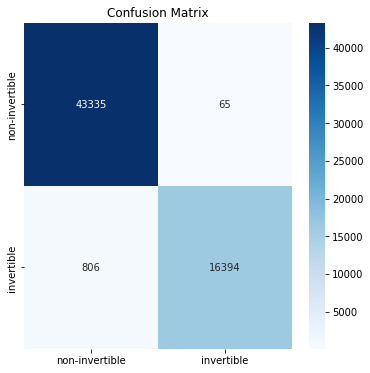

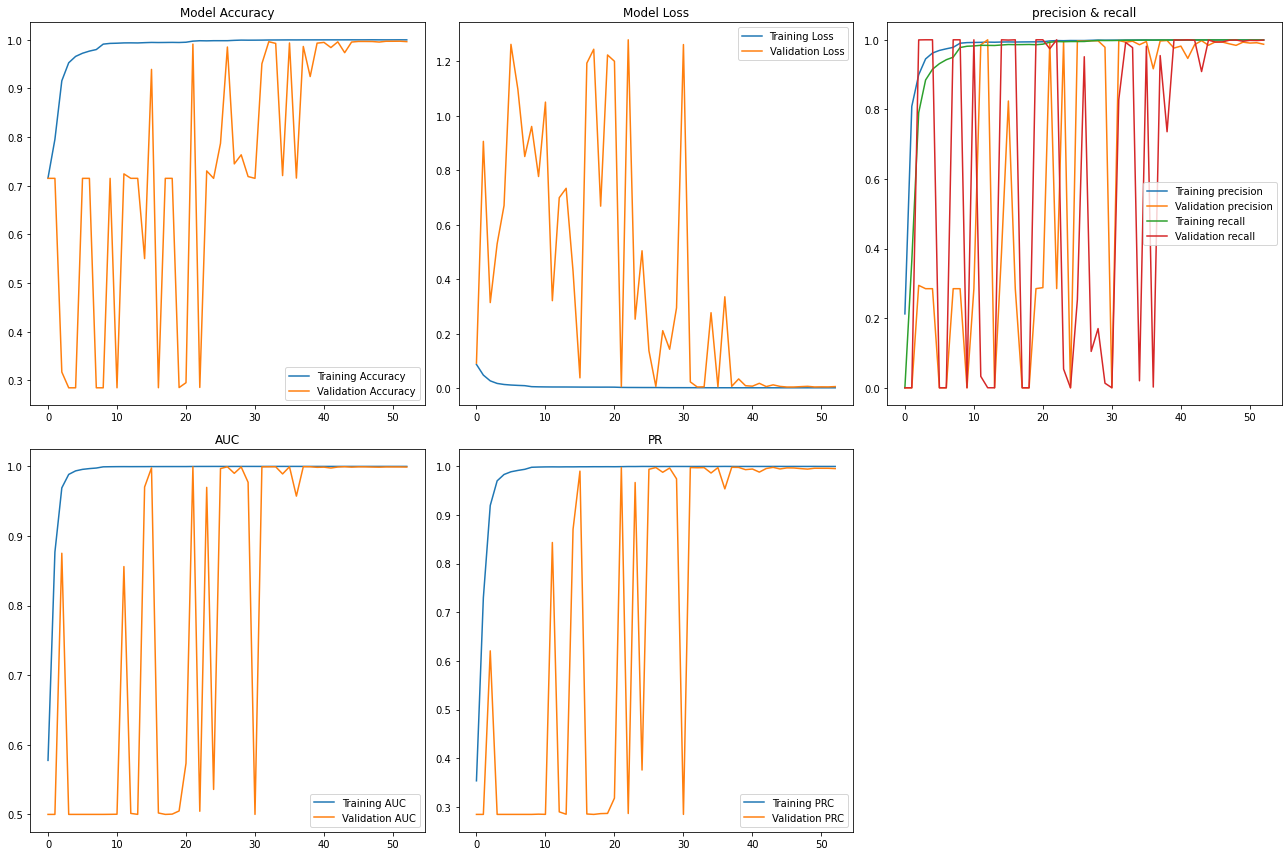

模型已保存

单位矩阵: 预测=0.9727 -> 可逆, 实际秩=128 -> 可逆, 正确

全1矩阵: 预测=0.9727 -> 可逆, 实际秩=1 -> 不可逆, 错误


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

def swish(x):
    return x * tf.sigmoid(x)

def gf2_rank_bitpack(matrix):
    n = matrix.shape[0]
    rows = []
    for i in range(n):
        row_val = 0
        for j in range(n):
            if matrix[i, j] == 1:
                row_val |= (1 << (127 - j))
        rows.append(row_val)
    rank = 0
    for col in range(n):
        bit_mask = 1 << (127 - col)
        pivot = -1
        for r in range(rank, n):
            if rows[r] & bit_mask:
                pivot = r
                break
        if pivot == -1:
            continue
        rows[rank], rows[pivot] = rows[pivot], rows[rank]
        for r in range(rank + 1, n):
            if rows[r] & bit_mask:
                rows[r] ^= rows[rank]
        rank += 1
    return rank

def generate_dataset(num_samples=20000):
    print(f"生成 {num_samples} 个128×128矩阵 (int8)...")
    start_time = time.time()
    matrices = np.random.randint(0, 2, size=(num_samples, 128, 128), dtype=np.int8)
    batch_size = 256
    labels = np.zeros(num_samples, dtype=np.int32)
    for i in range(0, num_samples, batch_size):
        end_idx = min(i + batch_size, num_samples)
        batch = matrices[i:end_idx]
        ranks = [gf2_rank_bitpack(mat) for mat in batch]
        labels[i:end_idx] = (np.array(ranks) == 128).astype(np.int32)
    duration = time.time() - start_time
    print(f"完成，耗时 {duration:.2f}秒，可逆比例 {np.mean(labels):.2%}")
    return matrices, labels

def enhanced_augment_data(matrices, labels):
    """数据增强"""
    augmented_matrices = [matrices]
    augmented_labels = [labels]
    n = matrices.shape[1]

    # 行列操作只做1轮
    for _ in range(3):
        # 行交换
        swapped = matrices.copy()
        for i in range(len(matrices)):
            idx1, idx2 = np.random.choice(n, 2, replace=False)
            swapped[i, [idx1, idx2]] = swapped[i, [idx2, idx1]]
        augmented_matrices.append(swapped)
        augmented_labels.append(labels)

        # 列交换
        col_swapped = np.transpose(matrices.copy(), (0, 2, 1))
        for i in range(len(col_swapped)):
            idx1, idx2 = np.random.choice(n, 2, replace=False)
            col_swapped[i, [idx1, idx2]] = col_swapped[i, [idx2, idx1]]
        col_swapped = np.transpose(col_swapped, (0, 2, 1))
        augmented_matrices.append(col_swapped)
        augmented_labels.append(labels)

        # 行加法
        added = matrices.copy()
        for i in range(len(matrices)):
            src_idx, tgt_idx = np.random.choice(n, 2, replace=False)
            added[i, tgt_idx] = (added[i, tgt_idx] + added[i, src_idx]) % 2
        augmented_matrices.append(added)
        augmented_labels.append(labels)

    # 特殊奇异模式
    print("添加特殊奇异模式...")
    special = []
    num_special = 1000
    for _ in range(num_special):
        mat = np.random.randint(0, 2, (128,128), dtype=np.int8)
        if np.random.rand() > 0.5:
            mat[np.random.randint(0,128)] = 0
        else:
            mat[:, np.random.randint(0,128)] = 0
        special.append(mat)
    for _ in range(num_special):
        mat = np.random.randint(0, 2, (128,128), dtype=np.int8)
        if np.random.rand() > 0.5:
            r1,r2 = np.random.choice(128,2,replace=False)
            mat[r2] = mat[r1]
        else:
            c1,c2 = np.random.choice(128,2,replace=False)
            mat[:,c2] = mat[:,c1]
        special.append(mat)
    for _ in range(num_special):
        mat = np.random.randint(0, 2, (128,128), dtype=np.int8)
        if np.random.rand() > 0.5:
            r1,r2 = np.random.choice(128,2,replace=False)
            mat[r2] = (mat[r1] + mat[np.random.randint(0,128)]) % 2
        else:
            c1,c2 = np.random.choice(128,2,replace=False)
            mat[:,c2] = (mat[:,c1] + mat[:,np.random.randint(0,128)]) % 2
        special.append(mat)

    augmented_matrices.append(np.array(special))
    augmented_labels.append(np.zeros(len(special), dtype=np.int32))

    augmented_matrices = np.vstack(augmented_matrices)
    augmented_labels = np.concatenate(augmented_labels)
    return augmented_matrices, augmented_labels

def create_enhanced_model_v2():
    inputs = layers.Input(shape=(128,128,1))
    x = layers.Conv2D(64, (5,5), padding='same')(inputs)
    x = layers.Activation(swish)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.Activation(swish)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    
    def residual_block(x, filters):
        shortcut = x
        x = layers.Conv2D(filters, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.Activation(swish)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.Activation(swish)(x)
        x = layers.BatchNormalization()(x)
        if shortcut.shape[-1] != filters:
            shortcut = layers.Conv2D(filters, (1,1), padding='same')(shortcut)
        return layers.add([x, shortcut])
    
    x = residual_block(x, 128)
    x = layers.SpatialDropout2D(0.3)(x)
    x = layers.SeparableConv2D(256, (3,3), padding='same')(x)
    x = layers.Activation(swish)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    
    def cbam_block(input_feature, reduction_ratio=4):
        channel = layers.GlobalAveragePooling2D()(input_feature)
        channel = layers.Dense(input_feature.shape[-1] // reduction_ratio)(channel)
        channel = layers.Activation(swish)(channel)
        channel = layers.Dense(input_feature.shape[-1], activation='sigmoid')(channel)
        channel = layers.Reshape((1,1,input_feature.shape[-1]))(channel)
        x = layers.multiply([input_feature, channel])
        spatial = layers.Conv2D(1, (3,3), padding='same', activation='sigmoid')(x)
        return layers.multiply([x, spatial])
    
    x = cbam_block(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Activation(swish)(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Activation(swish)(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs, outputs)
    
    class BalancedFocalLoss(tf.keras.losses.Loss):
        def __init__(self, gamma=2.0, alpha=0.25, label_smoothing=0.1):
            super().__init__()
            self.gamma = gamma
            self.alpha = alpha
            self.label_smoothing = label_smoothing
        def call(self, y_true, y_pred):
            y_true = tf.cast(y_true, tf.float32)
            y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
            y_true = y_true * (1.0 - self.label_smoothing) + 0.5 * self.label_smoothing
            cross_entropy = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
            p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
            modulating_factor = tf.pow(1.0 - p_t, self.gamma)
            alpha_factor = y_true * self.alpha + (1 - y_true) * (1 - self.alpha)
            loss = alpha_factor * modulating_factor * cross_entropy
            return tf.reduce_mean(loss)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss=BalancedFocalLoss(gamma=2.0, alpha=0.3, label_smoothing=0.1),
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.AUC(name='prc', curve='PR'),
            tf.keras.metrics.SpecificityAtSensitivity(0.5, name='specificity')
        ]
    )
    return model

def get_enhanced_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(monitor='val_prc', patience=15, verbose=1, mode='max', restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_prc', factor=0.5, patience=5, min_lr=1e-7, verbose=1, mode='max'),
        tf.keras.callbacks.ModelCheckpoint(filepath='best_model.h5', monitor='val_prc', save_best_only=True, mode='max', verbose=1),
        tf.keras.callbacks.CSVLogger('training_log.csv', separator=',', append=False),
        tf.keras.callbacks.TensorBoard(log_dir='./logs', histogram_freq=1)
    ]

def plot_training_history(history):
    plt.figure(figsize=(18,12))
    plt.subplot(2,3,1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.legend()
    plt.subplot(2,3,2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.legend()
    plt.subplot(2,3,3)
    plt.plot(history.history['precision'], label='Training precision')
    plt.plot(history.history['val_precision'], label='Validation precision')
    plt.plot(history.history['recall'], label='Training recall')
    plt.plot(history.history['val_recall'], label='Validation recall')
    plt.title('precision & recall')
    plt.legend()
    plt.subplot(2,3,4)
    plt.plot(history.history['auc'], label='Training AUC')
    plt.plot(history.history['val_auc'], label='Validation AUC')
    plt.title('AUC')
    plt.legend()
    plt.subplot(2,3,5)
    plt.plot(history.history['prc'], label='Training PRC')
    plt.plot(history.history['val_prc'], label='Validation PRC')
    plt.title('PR')
    plt.legend()
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300)
    plt.show()

def evaluate_model(model, X_test, y_test):
    print("\n评估模型...")
    results = model.evaluate(X_test, y_test, verbose=0)
    metrics = dict(zip(['loss','accuracy','precision','recall','auc','prc','specificity'], results))
    print(f"准确率: {metrics['accuracy']:.4f}, 精度: {metrics['precision']:.4f}, 召回率: {metrics['recall']:.4f}, AUC: {metrics['auc']:.4f}, PRC: {metrics['prc']:.4f}")
    f1 = 2 * metrics['precision'] * metrics['recall'] / (metrics['precision'] + metrics['recall'] + 1e-7)
    print(f"F1分数: {f1:.4f}")
    y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
    y_true = y_test.flatten()
    print(classification_report(y_true, y_pred, target_names=['non-invertible','invertible']))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['non-invertible','invertible'], yticklabels=['non-invertible','invertible'])
    plt.title('Confusion Matrix')
    plt.savefig('confusion_matrix.png', dpi=300)
    plt.show()
    return metrics
#
def main():
    # 清除旧图，避免 input_2 错误
    tf.keras.backend.clear_session()
    # tf.reset_default_graph()
    
    num_samples = 30000          # 样本数，可调整为 1000~2000
    matrices, labels = generate_dataset(num_samples=num_samples)
    matrices, labels = enhanced_augment_data(matrices, labels)
    print(f"增强后数据量: {matrices.shape[0]}, 可逆比例: {np.mean(labels):.2%}")
    
    # 准备训练数据
    matrices = matrices.reshape((-1, 128, 128, 1)).astype(np.float32)
    labels = labels.reshape(-1, 1).astype(np.float32)
    
    X_train, X_test, y_train, y_test = train_test_split(
        matrices, labels, test_size=0.2, random_state=42, stratify=labels
    )
    print(f"训练集: {X_train.shape[0]}, 测试集: {X_test.shape[0]}")
    
    model = create_enhanced_model_v2()
    model.summary()
    
    print("\n开始训练...")
    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        batch_size=32,
        epochs=100,
        validation_split=0.15,
        callbacks=get_enhanced_callbacks(),
        verbose=1
    )
    print(f"训练完成，耗时 {(time.time()-start_time)/60:.2f} 分钟")
    
    evaluate_model(model, X_test, y_test)
    plot_training_history(history)
    model.save('matrix_invertibility_detector_v2.h5')
    print("模型已保存")
    
    # 测试
    test_cases = [(np.eye(128, dtype=np.int8), "单位矩阵"), (np.ones((128,128), dtype=np.int8), "全1矩阵")]
    for mat, name in test_cases:
        inp = mat.reshape(1,128,128,1).astype(np.float32)
        prob = model.predict(inp, verbose=0)[0][0]
        pred = prob > 0.5
        rank = gf2_rank_bitpack(mat)
        actual = (rank == 128)
        print(f"\n{name}: 预测={prob:.4f} -> {'可逆' if pred else '不可逆'}, 实际秩={rank} -> {'可逆' if actual else '不可逆'}, {'正确' if pred==actual else '错误'}")

if __name__ == "__main__":
    main()